# Phase 1 - Warm-Up: Adiabatic Preparation of a 2D Antiferromagnet

**CERN QTI Hackathon - Quantum twin of TmMgGaO4**

This standalone notebook is the Phase 1 toolchain check for the challenge. It builds a square Rydberg array, sweeps the laser controls quasi-adiabatically, and measures checkerboard antiferromagnetic order as a function of detuning.

What this notebook should prove before Phase 2:
1. The blockade radius is in the checkerboard window `a < R_b < a*sqrt(2)`.
2. Pulser sequence construction and exact emulation work end to end on a small array.
3. Staggered magnetisation and `S^zz(pi, pi)` both show AFM order building during the detuning sweep.
4. Larger-array scaling is documented as an optional, slower check rather than hidden in the main path.


In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt

from pulser import Pulse, Register, Sequence
from pulser.channels import Rydberg
from pulser.devices import VirtualDevice
from pulser.waveforms import CompositeWaveform, ConstantWaveform, RampWaveform
from pulser.backend import CorrelationMatrix, EmulationConfig, Occupation
from pulser_simulation import QutipBackendV2

np.set_printoptions(precision=3, suppress=True)


# Standalone Phase-1 helpers.
def build_device(rydberg_level: int = 60, min_atom_distance: float = 4.0) -> VirtualDevice:
    return VirtualDevice(
        name=f"phase1_square_afm_n{rydberg_level}",
        dimensions=2,
        rydberg_level=rydberg_level,
        min_atom_distance=min_atom_distance,
        channel_objects=(Rydberg.Global(max_abs_detuning=None, max_amp=None),),
    )


def square_register(rows: int, cols: int, spacing: float, prefix: str = "q") -> Register:
    return Register.rectangle(rows, cols, spacing=spacing, prefix=prefix)


def afm_prep_sequence(
    register: Register,
    device: VirtualDevice,
    Omega_max: float,
    delta_start: float,
    delta_end: float,
    t_rise: int,
    t_sweep: int,
    t_fall: int,
) -> Sequence:
    seq = Sequence(register, device)
    seq.declare_channel("ryd", "rydberg_global")
    amp = CompositeWaveform(
        RampWaveform(t_rise, 0.0, Omega_max),
        ConstantWaveform(t_sweep, Omega_max),
        RampWaveform(t_fall, Omega_max, 0.0),
    )
    det = RampWaveform(t_rise + t_sweep + t_fall, delta_start, delta_end)
    seq.add(Pulse(amp, det, 0.0), "ryd")
    return seq


def controls_at_fraction(
    fractions: np.ndarray,
    Omega_max: float,
    delta_start: float,
    delta_end: float,
    t_rise: int,
    t_sweep: int,
    t_fall: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return Omega(t) and delta(t) at Pulser observable fractions."""
    fractions = np.asarray(fractions, dtype=float)
    total = t_rise + t_sweep + t_fall
    t = fractions * total
    omega = np.zeros_like(t, dtype=float)

    rising = t <= t_rise
    plateau = (t > t_rise) & (t <= t_rise + t_sweep)
    falling = t > t_rise + t_sweep
    omega[rising] = Omega_max * t[rising] / t_rise
    omega[plateau] = Omega_max
    omega[falling] = Omega_max * (total - t[falling]) / t_fall
    omega = np.clip(omega, 0.0, Omega_max)

    delta = delta_start + fractions * (delta_end - delta_start)
    return omega, delta


def sz_from_occupation(occupation: np.ndarray) -> np.ndarray:
    return 1.0 - 2.0 * np.asarray(occupation, dtype=float)


def sz_correlation_from_occupation(occupation: np.ndarray, n_corr: np.ndarray) -> np.ndarray:
    occupation = np.asarray(occupation, dtype=float)
    n_corr = np.asarray(n_corr, dtype=float)
    return 1.0 - 2.0 * occupation[:, None] - 2.0 * occupation[None, :] + 4.0 * n_corr


def checkerboard_signs(n_side: int) -> np.ndarray:
    return np.fromfunction(lambda i, j: (-1.0) ** (i + j), (n_side, n_side)).reshape(-1)


def staggered_magnetisation(occupation: np.ndarray, n_side: int) -> float:
    return float(np.mean(sz_from_occupation(occupation) * checkerboard_signs(n_side)))


def checkerboard_structure_factor(
    occupation: np.ndarray,
    n_corr: np.ndarray,
    n_side: int,
    connected: bool = False,
) -> float:
    """S(pi, pi)/N for the square AFM pattern.

    The full version is the order diagnostic: it remains O(N) for a
    checkerboard-ordered state. The connected version removes
    <sz_i><sz_j>, so it measures residual fluctuations around the ordered
    pattern and can be small for a near-product state.
    """
    signs = checkerboard_signs(n_side)
    sz = sz_from_occupation(occupation)
    sz_corr = sz_correlation_from_occupation(occupation, n_corr)
    if connected:
        sz_corr = sz_corr - np.outer(sz, sz)
    return float(signs @ sz_corr @ signs / len(signs))




## 1. Register and Blockade-Radius Tuning

Checkerboard order needs nearest neighbours to block each other while diagonal neighbours remain mostly available. The quick sanity condition is `a < R_b < a*sqrt(2)`. Here `R_b/a = 1.2`, safely inside that window.


In [13]:
n_side = 3
spacing = 5.0  # um
device = build_device(rydberg_level=60, min_atom_distance=4.0)

register = square_register(n_side, n_side, spacing=spacing)
Rb_ratio = 1.2
Rb = Rb_ratio * spacing
Omega_max = device.rabi_from_blockade(Rb)

print(f"N = {len(register.qubits)} atoms, spacing a = {spacing:.1f} um")
print(f"Blockade radius Rb = {Rb:.2f} um  (a={spacing:.1f}, a*sqrt(2)={spacing*np.sqrt(2):.2f})")
print(f"Omega_max / 2pi = {Omega_max/(2*np.pi):.3f} MHz")


N = 9 atoms, spacing a = 5.0 um
Blockade radius Rb = 6.00 um  (a=5.0, a*sqrt(2)=7.07)
Omega_max / 2pi = 2.953 MHz


## 2. Quasi-Adiabatic Sequence and Emulation

The pulse ramps `Omega` up, sweeps detuning `delta` from negative to positive, then ramps `Omega` back down to freeze the final z-basis population before readout. The observable times are later converted back to `delta/2pi`, because the Phase 1 deliverable is an order parameter versus the sweep/control parameter.


Sequence duration: 2000 ns
Detuning sweep: -8.0 -> 8.0 MHz


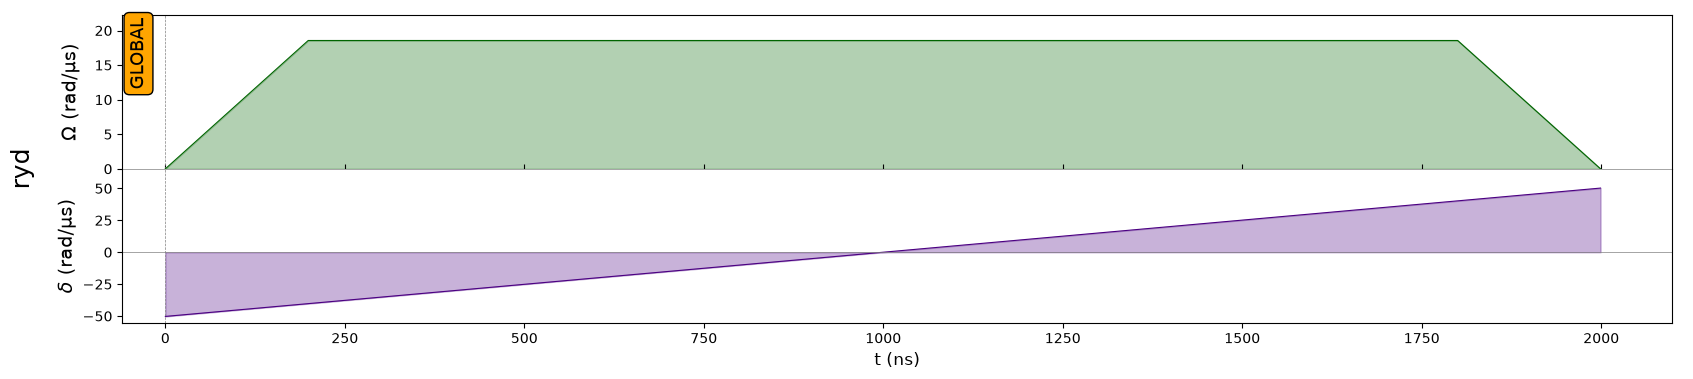

In [14]:
delta_start = -2 * np.pi * 8.0  # rad/us: deep paramagnet
delta_end = 2 * np.pi * 8.0     # rad/us: favours checkerboard order
t_rise, t_sweep, t_fall = 200, 1600, 200  # ns


seq = afm_prep_sequence(
    register,
    device,
    Omega_max=Omega_max,
    delta_start=delta_start,
    delta_end=delta_end,
    t_rise=t_rise,
    t_sweep=t_sweep,
    t_fall=t_fall,
)
print(f"Sequence duration: {seq.get_duration()} ns")
print(f"Detuning sweep: {delta_start/(2*np.pi):.1f} -> {delta_end/(2*np.pi):.1f} MHz")
seq.draw()


In [15]:
eval_times = np.linspace(0.05, 1.0, 25).tolist()
cfg = EmulationConfig(
    observables=[
        Occupation(evaluation_times=eval_times),
        CorrelationMatrix(evaluation_times=eval_times),
    ]
)

t0 = time.time()
backend = QutipBackendV2(seq, config=cfg)
results = backend.run()
print(f"Emulation took {time.time() - t0:.1f} s")


Emulation took 0.3 s


## 3. Order Diagnostics Versus Detuning

The staggered magnetisation is the direct real-space checkerboard diagnostic. The full `S^zz(pi, pi)` is the corresponding structure factor; for a perfectly ordered `3x3` product state it is `O(N)`. The connected structure factor subtracts `<sz_i><sz_j>`, so it measures residual fluctuations around the ordered pattern and can be small once the state is nearly classical.


In [16]:
m_stag, Szz_full, Szz_connected = [], [], []
for occ, corr in zip(results.occupation, results.correlation_matrix):
    occ = np.asarray(occ, dtype=float)
    corr = np.asarray(corr, dtype=float)
    m_stag.append(staggered_magnetisation(occ, n_side))
    Szz_full.append(checkerboard_structure_factor(occ, corr, n_side, connected=False))
    Szz_connected.append(checkerboard_structure_factor(occ, corr, n_side, connected=True))

m_stag = np.asarray(m_stag)
Szz_full = np.asarray(Szz_full)
Szz_connected = np.asarray(Szz_connected)
times_ns = np.asarray(eval_times) * seq.get_duration()
Omega_values, delta_values = controls_at_fraction(
    eval_times, Omega_max, delta_start, delta_end, t_rise, t_sweep, t_fall
)
detuning_mhz = delta_values / (2 * np.pi)
omega_mhz = Omega_values / (2 * np.pi)

print(f"Final |m_stag| = {abs(m_stag[-1]):.3f}")
print(f"Final S^zz(pi,pi) = {Szz_full[-1]:.3f}  (max scale is N={n_side**2})")
print(f"Final connected S^zz(pi,pi) = {Szz_connected[-1]:.3f}")


Final |m_stag| = 0.970
Final S^zz(pi,pi) = 8.619  (max scale is N=9)
Final connected S^zz(pi,pi) = 0.144


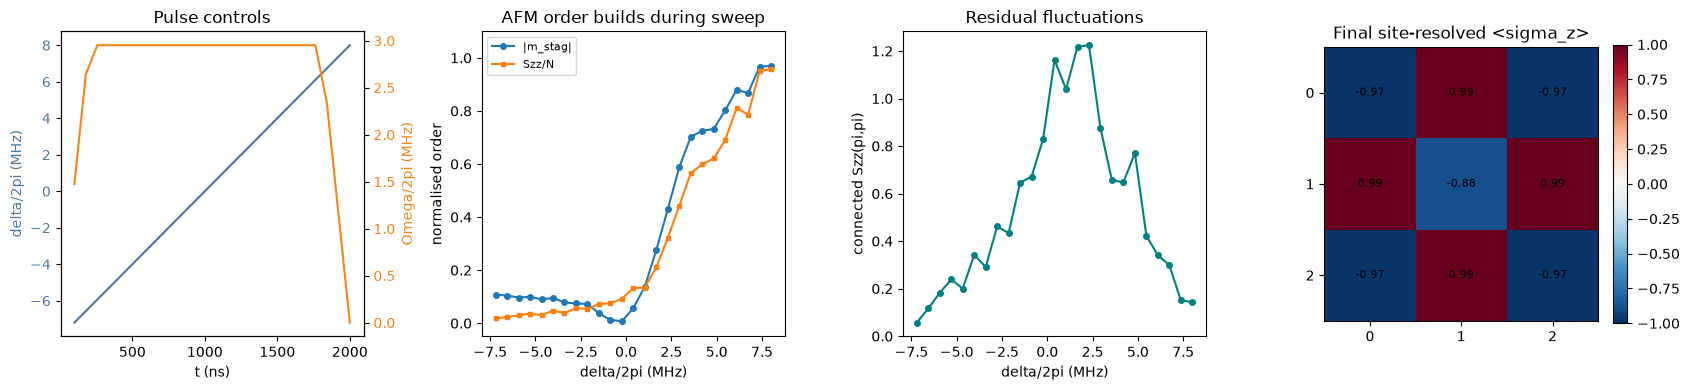

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

ax_ctrl = axes[0]
ax_ctrl.plot(times_ns, detuning_mhz, color="#4c78a8", label="delta/2pi")
ax_ctrl.set_xlabel("t (ns)")
ax_ctrl.set_ylabel("delta/2pi (MHz)", color="#4c78a8")
ax_ctrl.tick_params(axis="y", labelcolor="#4c78a8")
ax_omega = ax_ctrl.twinx()
ax_omega.plot(times_ns, omega_mhz, color="#f58518", label="Omega/2pi")
ax_omega.set_ylabel("Omega/2pi (MHz)", color="#f58518")
ax_omega.tick_params(axis="y", labelcolor="#f58518")
ax_ctrl.set_title("Pulse controls")

axes[1].plot(detuning_mhz, np.abs(m_stag), "-o", ms=4, label="|m_stag|")
axes[1].plot(detuning_mhz, Szz_full / n_side**2, "-s", ms=3, label="Szz/N")
axes[1].set_xlabel("delta/2pi (MHz)")
axes[1].set_ylabel("normalised order")
axes[1].set_title("AFM order builds during sweep")
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=8)

axes[2].plot(detuning_mhz, Szz_connected, "-o", ms=4, color="teal")
axes[2].set_xlabel("delta/2pi (MHz)")
axes[2].set_ylabel("connected Szz(pi,pi)")
axes[2].set_title("Residual fluctuations")

final_occ = np.asarray(results.occupation[-1], dtype=float)
sz_grid = sz_from_occupation(final_occ).reshape(n_side, n_side)
im = axes[3].imshow(sz_grid, cmap="RdBu_r", vmin=-1, vmax=1)
axes[3].set_title("Final site-resolved <sigma_z>")
axes[3].set_xticks(range(n_side))
axes[3].set_yticks(range(n_side))
for i in range(n_side):
    for j in range(n_side):
        axes[3].text(j, i, f"{sz_grid[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.savefig("phase1_afm_result.png", dpi=140)
plt.show()


## 4. Optional 4x4 Scaling Check

The challenge expects Phase 1 to be a fast checkpoint, so the main path stays at `3x3`. The same simple linear-ramp recipe does not automatically scale to larger arrays because the many-body gap shrinks. The cell below is guarded: exact `4x4` emulation can take minutes on CPU, but it is useful when you want to document how the naive ramp begins to fail.


In [18]:
RUN_N16_EXACT = False

if RUN_N16_EXACT:
    n_side_big = 4
    register_big = square_register(n_side_big, n_side_big, spacing=spacing)
    seq_big = afm_prep_sequence(
        register_big,
        device,
        Omega_max=Omega_max,
        delta_start=delta_start,
        delta_end=delta_end,
        t_rise=300,
        t_sweep=3500,
        t_fall=300,
    )
    cfg_big = EmulationConfig(observables=[Occupation(evaluation_times=[1.0])])
    t0 = time.time()
    res_big = QutipBackendV2(seq_big, config=cfg_big).run()
    print(f"N={n_side_big**2} exact emulation took {time.time() - t0:.1f} s")

    occ_big = np.asarray(res_big.occupation[-1], dtype=float)
    sz_big = sz_from_occupation(occ_big).reshape(n_side_big, n_side_big)
    m_big = staggered_magnetisation(occ_big, n_side_big)
    print(f"N={n_side_big**2} staggered magnetisation: {m_big:.4f}")
    print(sz_big.round(3))
else:
    print("Skipped exact N=16 run. Set RUN_N16_EXACT = True to run the slow scaling check.")


Skipped exact N=16 run. Set RUN_N16_EXACT = True to run the slow scaling check.


### Interpretation

For `3x3`, this is the intended Phase 1 deliverable: a self-contained Pulser notebook showing checkerboard order building as detuning is swept. The useful figure for the write-up is `phase1_afm_result.png`: it shows the pulse controls, order parameters versus detuning, connected fluctuations, and the final site-resolved spin pattern.

For larger arrays, use this as the baseline rather than the final protocol. Increase sweep time, tune detuning endpoints, or move to an optimized pulse shape before interpreting a low-order result as a simulator limitation.
